In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
# Read Data
client_data = pd.read_csv('client_data.csv')
price_data = pd.read_csv('price_data.csv')

In [65]:
pd.set_option('display.max_columns', None)
client_data.head()

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,0,0.0,1.78,0.114481,0.098142,40.606701,t,0.00,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,0,0.0,16.27,0.145711,0.000000,44.311378,f,0.00,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,0,0.0,38.72,0.165794,0.087899,44.311378,f,0.00,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,0,0.0,19.83,0.146694,0.000000,44.311378,f,0.00,30.22,30.22,1,25.46,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.200,0
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,526,0.0,131.73,0.116900,0.100015,40.606701,f,52.32,44.91,44.91,1,47.98,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,19.800,0


First remarks:
- cons_12m: renamed to cons_elec_12m

In [66]:
price_data.head()

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0
3,038af19179925da21a25619c5a24b745,2015-04-01,0.149626,0.0,0.0,44.266931,0.0,0.0
4,038af19179925da21a25619c5a24b745,2015-05-01,0.149626,0.0,0.0,44.266931,0.0,0.0


In [67]:
# Data types
client_data.dtypes

id                                    str
channel_sales                         str
cons_12m                            int64
cons_gas_12m                        int64
cons_last_month                     int64
date_activ                            str
date_end                              str
date_modif_prod                       str
date_renewal                          str
forecast_cons_12m                 float64
forecast_cons_year                  int64
forecast_discount_energy          float64
forecast_meter_rent_12m           float64
forecast_price_energy_off_peak    float64
forecast_price_energy_peak        float64
forecast_price_pow_off_peak       float64
has_gas                               str
imp_cons                          float64
margin_gross_pow_ele              float64
margin_net_pow_ele                float64
nb_prod_act                         int64
net_margin                        float64
num_years_antig                     int64
origin_up                         

In [68]:
client_data["date_activ"] = pd.to_datetime(client_data["date_activ"])
client_data["date_end"] = pd.to_datetime(client_data["date_end"])
client_data["date_modif_prod"] = pd.to_datetime(client_data["date_modif_prod"])
client_data["date_renewal"] = pd.to_datetime(client_data["date_renewal"])

In [69]:
price_data.dtypes

id                        str
price_date                str
price_off_peak_var    float64
price_peak_var        float64
price_mid_peak_var    float64
price_off_peak_fix    float64
price_peak_fix        float64
price_mid_peak_fix    float64
dtype: object

In [70]:
price_data["price_date"] = pd.to_datetime(price_data["price_date"])

# Visuals

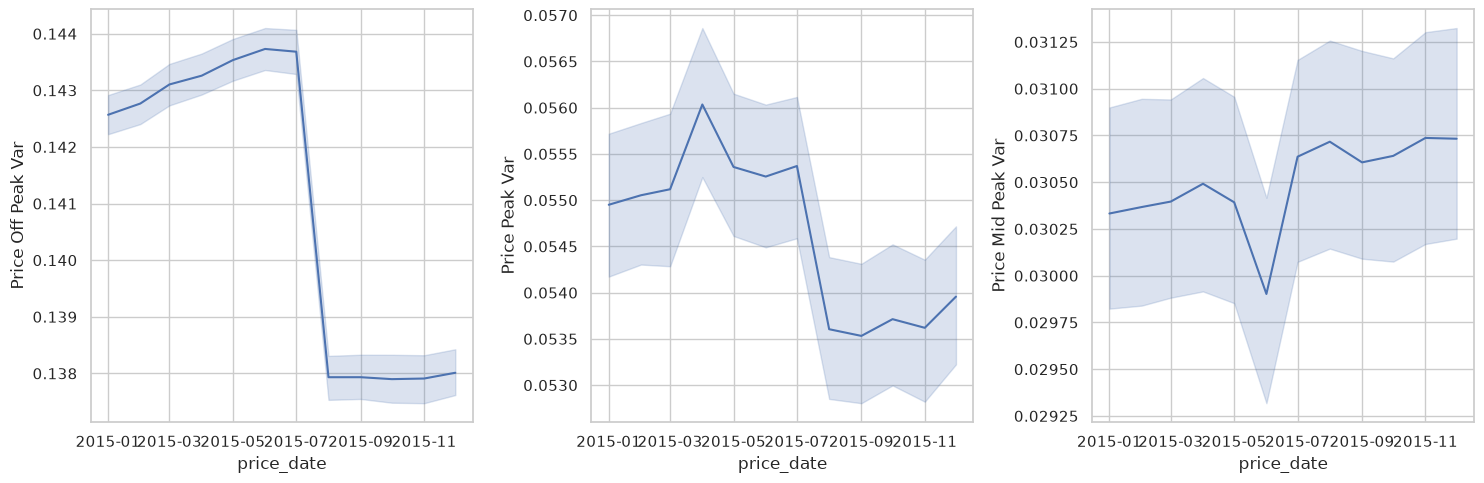

In [71]:
# developement of price of energy over time
fig, axes = plt.subplots(1,3, figsize=(15,5))
sns.set_theme(style="whitegrid")

sns.lineplot(data=price_data, x="price_date", y="price_off_peak_var", linewidth=1.5, ax=axes[0])
axes[0].set_ylabel("Price Off Peak Var") 
sns.lineplot(data=price_data, x="price_date", y="price_peak_var", linewidth=1.5, ax=axes[1])
axes[1].set_ylabel("Price Peak Var")
sns.lineplot(data=price_data, x="price_date", y="price_mid_peak_var", linewidth=1.5, ax=axes[2])
axes[2].set_ylabel("Price Mid Peak Var")
plt.tight_layout()

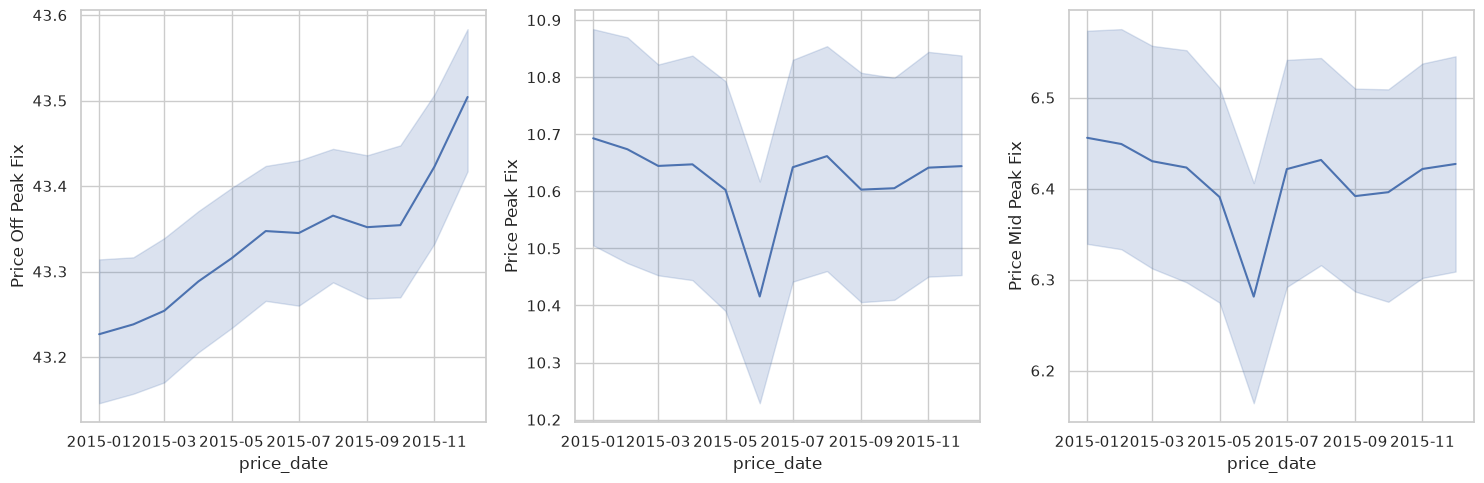

In [72]:
# development of price of power over time
fig, axes = plt.subplots(1,3, figsize=(15,5))
sns.lineplot(data=price_data, x="price_date", y="price_off_peak_fix", linewidth=1.5, ax=axes[0])
axes[0].set_ylabel("Price Off Peak Fix")
sns.lineplot(data=price_data, x="price_date", y="price_peak_fix", linewidth=1.5, ax=axes[1])
axes[1].set_ylabel("Price Peak Fix")
sns.lineplot(data=price_data, x="price_date", y="price_mid_peak_fix", linewidth=1.5, ax=axes[2])
axes[2].set_ylabel("Price Mid Peak Fix")
plt.tight_layout() 

Text(0.5, 0, 'Churn (0 = retained, 1 = churned)')

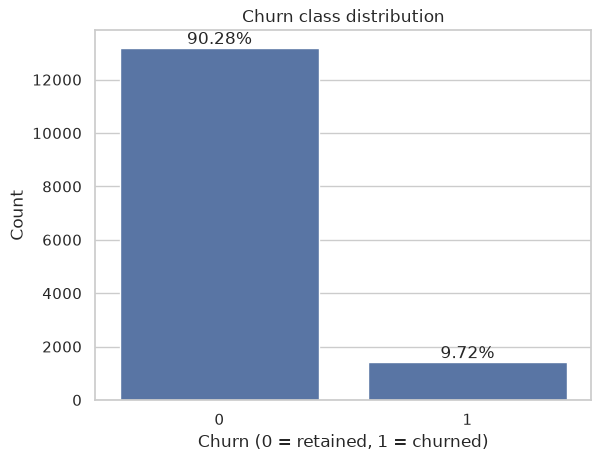

In [73]:
ax = sns.barplot(data=client_data["churn"].value_counts().reset_index(), x="churn", y="count")
churn_perc = (client_data['churn'].value_counts()[0] /len(client_data.churn))*100
retention_perc = (client_data['churn'].value_counts()[1] /len(client_data.churn))*100
ax.annotate(f"{churn_perc:.2f}%", xy=(0, client_data['churn'].value_counts()[0]), ha='center', va='bottom')
ax.annotate(f"{retention_perc:.2f}%", xy=(1, client_data['churn'].value_counts()[1]), ha='center', va='bottom')
ax.set_ylabel("Count")
ax.set_title("Churn class distribution")
ax.set_xlabel("Churn (0 = retained, 1 = churned)")

<Axes: >

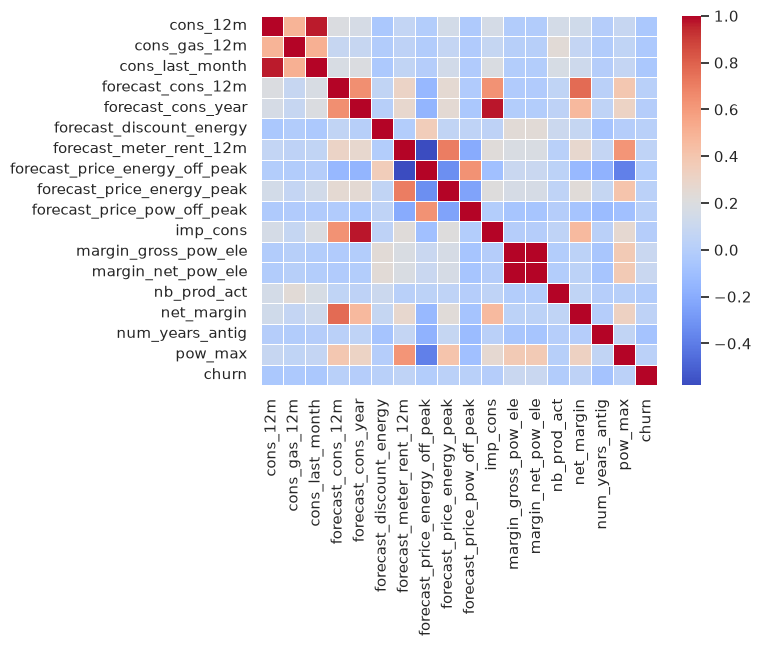

In [74]:
sns.heatmap(client_data.corr(numeric_only=True), cmap='coolwarm', fmt=".2f", linewidths=0.5)

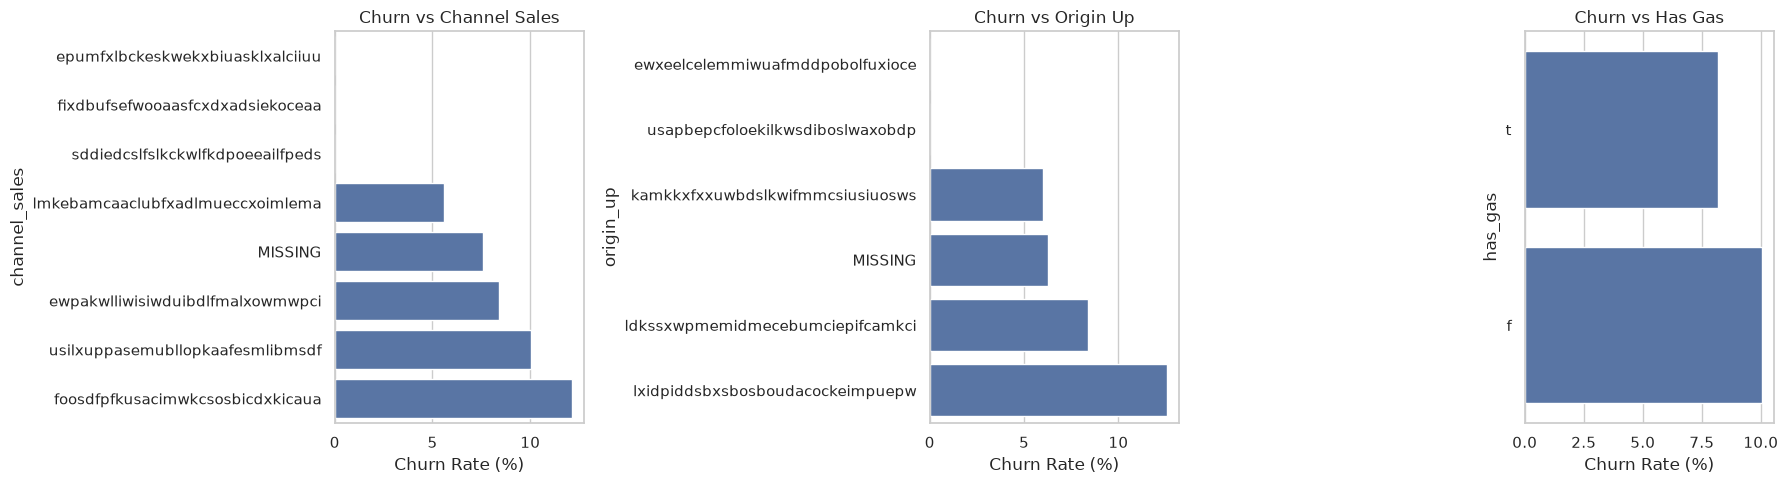

In [82]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

churn_by_channel_sales = client_data.groupby("channel_sales")["churn"].mean().mul(100).reset_index().sort_values(by="churn", ascending=True)
churn_by_has_gas = client_data.groupby("has_gas")["churn"].mean().mul(100).reset_index().sort_values(by="churn", ascending=True)
churn_by_origin_up = client_data.groupby("origin_up")["churn"].mean().mul(100).reset_index().sort_values(by="churn", ascending=True)

sns.barplot(data=churn_by_channel_sales, x="churn", y="channel_sales", ax=axes[0])
axes[0].set_xlabel("Churn Rate (%)")
axes[0].set_title("Churn vs Channel Sales")
sns.barplot(data=churn_by_has_gas, x="churn", y="has_gas", ax=axes[2])
axes[2].set_xlabel("Churn Rate (%)")
axes[2].set_title("Churn vs Has Gas")
sns.barplot(data=churn_by_origin_up, x="churn", y="origin_up", ax=axes[1])
axes[1].set_xlabel("Churn Rate (%)")
axes[1].set_title("Churn vs Origin Up")

plt.tight_layout()